# Broken-power-law model-mismatch test

This notebook tests when non-parametric spectral reconstruction becomes useful. It injects a broken power law with a fixed 1000 keV break and low-energy index $-1.5$. The post-break index is $-1.5$ (control: no break), $-2.5$ (moderate mismatch), or $-4$ (strong mismatch). The frozen methods are deliberately based on a globally fitted single power law, so their spectral family becomes increasingly incorrect.

Four reconstructions are compared: simultaneous BinnedSED, simultaneous frozen-global-index bins, individual measured-energy frozen-shape fits, and point-source Richardson-Lucy. All data are generated with `SourceInjector` and the same DC4 response/background. The orientation is restricted in memory to times when the source is within 60 degrees of the pointing direction, matching the background product's FOV selection. RL detections have no vertical error bars; all methods use $TS<1$ for 95% upper-limit reporting. The internal global single-power-law fit is used only to define the frozen within-bin index and background; it is not reported as a separate reconstruction.

## 1. Imports and mismatch cases

In [1]:
from pathlib import Path
from functools import lru_cache
from types import MethodType
import shutil
import tempfile

import cosipy
import astropy.units as u
from astropy.coordinates import SkyCoord
from astromodels import Broken_powerlaw, Model, Parameter, PointSource, Powerlaw
from histpy import Histogram
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import quad
from scipy.optimize import brentq, minimize, minimize_scalar
from threeML import DataList, JointLikelihood, PluginPrototype

from cosipy import BinnedData
from cosipy.data_io import EmCDSBinnedData
from cosipy.image_deconvolution import select_orientation_for_pointing_cut
from cosipy.response import BinnedInstrumentResponse, PointSourceResponse
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.source_injector import SourceInjector
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.threeml import BinnedSED


# Consistent DC4 orientation, response, and background products.
DC4_DATA_DIR = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "COSI/Radio_Quiet_AGN/DC4_Files"
)

AGN_ORIENTATION_CANDIDATES = [
    DC4_DATA_DIR / "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits",
]
AGN_RESPONSE_CANDIDATES = [
    DC4_DATA_DIR / (
        "ResponseContinuum.o3.e100_10000.b10log."
        "s10396905069491.m2284.filtered.nonsparse.binnedimaging."
        "imagingresponse.h5"
    ),
]
AGN_BACKGROUND_CANDIDATES = [
    DC4_DATA_DIR / (
        "Background/Total_DC4_BG_3months_binned_data_filtered_"
        "with_SAAcut_withSAAbck_NGC4151_60deg_fov_cut.hdf5"
    ),
]
AGN_YAML_NAMES = (
    "background.yaml",
    "NGC4151_ec200.yaml",
    "NGC4151_ec1000.yaml",
)
AGN_YAML_SEARCH_DIRS = (
    Path("."),
    Path("docs/tutorials/spectral_fits/sed_model"),
    Path(cosipy.__file__).resolve().parents[1]
    / "docs/tutorials/spectral_fits/sed_model",
)

BREAK_ENERGY_KEV = 1000.0
INJECTED_LOW_INDEX = -1.5
INJECTED_HIGH_INDICES = (-1.5, -2.5, -4.0)
LOCAL_SED_INDEX = -2.0
INITIAL_BIN_FLUX = 1.0e-7  # common, data-independent starting K_i
MINUIT_START_FLUXES = (1.0e-9, 1.0e-8, 1.0e-7, 1.0e-6, 1.0e-5)
RL_ITERATIONS = 1000
RL_INITIAL_BAND_FLUX = 1.0e-4
TS_THRESHOLD = 1.0
INTEGRATED_PHOTON_FLUX = 3.0e-4  # chosen to produce detections and TS < 1 bins
POWERLAW_PIVOT_KEV = 200.0
SOURCE_LONGITUDE_DEG = 155.07
SOURCE_LATITUDE_DEG = 75.06
FOV_CUT = 60 * u.deg
PHOTON_FLUX_DENSITY_UNIT = 1.0 / (u.keV * u.cm**2 * u.s)



12:23:22 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=938870;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=553712;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=401981;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=794076;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=192888;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=236166;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

12:23:22 INFO      Starting 3ML!                                                                     ]8;id=575787;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=408266;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

WARNING   WARNINGs here are NOT errors                                                      ]8;id=812075;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=511126;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=514197;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=678953;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

WARNING   No fermitools installed                                              ]8;id=514506;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=107753;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=855197;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=873597;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=119505;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=312030;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=754246;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=939260;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

## 2. DC4 and spectral helpers

In [2]:

def _first_existing_path(candidates, label):
    for path in candidates:
        if path.exists():
            return path
    attempted = "\n".join(f"  - {path}" for path in candidates)
    raise FileNotFoundError(f"Could not find the {label}. Tried:\n{attempted}")


def _resolve_agn_yamls():
    return {
        name: _first_existing_path(
            [directory / name for directory in AGN_YAML_SEARCH_DIRS],
            f"copied AGN YAML {name}",
        )
        for name in AGN_YAML_NAMES
    }


def _dense_values(histogram):
    values = histogram.contents
    if hasattr(values, "todense"):
        values = values.todense()
    if isinstance(values, u.Quantity):
        values = values.value
    return np.asarray(values, dtype=float)


def _open_agn_orientation(path):
    """Open the branch .ori file, tolerating its missing final EN marker."""
    try:
        return SpacecraftHistory.open(path)
    except ValueError as error:
        if "must end with final line 'EN'" not in str(error):
            raise
        with tempfile.NamedTemporaryFile(suffix=".ori") as repaired:
            with path.open("rb") as original:
                shutil.copyfileobj(original, repaired)
            repaired.write(b"EN\n")
            repaired.flush()
            return SpacecraftHistory.open(repaired.name)


def _open_compatible_response(candidates):
    """Prefer the branch response, skipping legacy formats this reader rejects."""
    failures = []
    for path in candidates:
        if not path.exists():
            continue
        try:
            return path, FullDetectorResponse.open(path)
        except RuntimeError as error:
            if "Response format is version" not in str(error):
                raise
            failures.append(f"{path}: {error}")
    detail = "\n".join(failures) or "no candidate files exist"
    raise RuntimeError(f"No compatible AGN response was found:\n{detail}")


def _axis_edges_keV(axis):
    edges = axis.edges
    if isinstance(edges, u.Quantity):
        return np.asarray(edges.to_value(u.keV), dtype=float)
    return np.asarray(edges, dtype=float)


def _powerlaw_integral_coefficient(index, pivot, elo, ehi):
    if np.isclose(index, -1.0):
        return pivot * np.log(ehi / elo)
    return (
        pivot ** (-index)
        * (ehi ** (index + 1.0) - elo ** (index + 1.0))
        / (index + 1.0)
    )


def _make_powerlaw(index, normalization, pivot=POWERLAW_PIVOT_KEV):
    spectrum = Powerlaw()
    spectrum.set_units(u.keV, PHOTON_FLUX_DENSITY_UNIT)
    spectrum.K.value = float(normalization)
    spectrum.piv.value = float(pivot)
    spectrum.index.value = float(index)
    return spectrum



def _correct_broken_powerlaw_evaluate(self, x, K, xb, alpha, beta, piv):
    """Evaluate both branches correctly for unit-bearing energies."""
    has_units = isinstance(x, u.Quantity)
    energy = x.to_value(self.x_unit) if has_units else np.asarray(x)

    def value(parameter):
        return parameter.value if isinstance(parameter, u.Quantity) else parameter

    break_energy = value(xb)
    result = value(K) * np.where(
        energy < break_energy,
        (energy / break_energy) ** value(alpha),
        (energy / break_energy) ** value(beta),
    )
    return result * self.y_unit if has_units else result


def _make_broken_powerlaw(
    high_index,
    normalization,
    break_energy_keV=BREAK_ENERGY_KEV,
    low_index=INJECTED_LOW_INDEX,
):
    spectrum = Broken_powerlaw()
    # astromodels 2.5.0 accidentally substitutes alpha for beta when x has
    # units. SourceInjector evaluates unit-bearing energies, so bind the
    # mathematically documented piecewise evaluator to this instance.
    spectrum.evaluate = MethodType(_correct_broken_powerlaw_evaluate, spectrum)
    spectrum.set_units(u.keV, PHOTON_FLUX_DENSITY_UNIT)
    spectrum.K.value = float(normalization)
    spectrum.xb.value = float(break_energy_keV)
    spectrum.alpha.value = float(low_index)
    spectrum.beta.value = float(high_index)
    spectrum.piv.value = POWERLAW_PIVOT_KEV
    return spectrum


def _broken_powerlaw_shape(
    energy_keV,
    high_index,
    break_energy_keV=BREAK_ENERGY_KEV,
    low_index=INJECTED_LOW_INDEX,
):
    energy_keV = np.asarray(energy_keV, dtype=float)
    ratio = energy_keV / float(break_energy_keV)
    return np.where(
        energy_keV < break_energy_keV,
        ratio ** float(low_index),
        ratio ** float(high_index),
    )


def _broken_powerlaw_integral_coefficient(
    high_index,
    break_energy_keV,
    low_index,
    emin_keV,
    emax_keV,
):
    value, _ = quad(
        lambda energy: float(
            _broken_powerlaw_shape(
                energy, high_index, break_energy_keV, low_index
            )
        ),
        float(emin_keV),
        float(emax_keV),
        epsabs=0.0,
        epsrel=1.0e-10,
        points=[float(break_energy_keV)]
        if emin_keV < break_energy_keV < emax_keV
        else None,
    )
    return float(value)


## 3. Shared Poisson and 3ML/Minuit helpers

In [3]:

def _poisson_nll(data, model):
    """Poisson deviance / 2, with the saturated-model constant removed."""
    model = np.clip(np.asarray(model, dtype=float), np.finfo(float).tiny, None)
    data = np.asarray(data, dtype=float)
    positive = data > 0.0
    value = np.sum(model[~positive])
    value += np.sum(
        model[positive]
        - data[positive]
        + data[positive] * np.log(data[positive] / model[positive])
    )
    return float(value)


def _fit_positive_components(data, components, start=None, fixed_model=None):
    """Fit non-negative amplitudes multiplying fixed detector-space templates."""
    data = np.asarray(data, dtype=float).ravel()
    components = np.asarray(components, dtype=float).reshape(len(components), -1)
    if fixed_model is None:
        fixed_model = np.zeros_like(data)
    else:
        fixed_model = np.asarray(fixed_model, dtype=float).ravel()

    if start is None:
        start = np.ones(components.shape[0])
    start = np.clip(np.asarray(start, dtype=float), 1.0e-30, None)

    # Parameterize each coefficient by its expected component counts. This
    # removes the enormous column-scale differences produced by steep cutoffs.
    component_sums = np.sum(components, axis=1)
    if np.any(~np.isfinite(component_sums)) or np.any(component_sums <= 0.0):
        raise ValueError("Every fitted component must have a positive finite sum.")
    normalized_components = components / component_sums[:, None]
    expected_counts = start * component_sums
    tiny = np.finfo(float).tiny

    # Multiplicative Poisson updates provide a robust warm start while retaining
    # the exact physical starting amplitudes supplied above.
    for _ in range(100):
        raw_model = fixed_model + expected_counts @ normalized_components
        model = np.clip(raw_model, tiny, None)
        ratio = np.zeros_like(data)
        supported = (raw_model > tiny) & (data > 0.0)
        with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
            ratio[supported] = data[supported] / model[supported]
        ratio = np.nan_to_num(ratio, nan=0.0, posinf=1.0e100, neginf=0.0)
        updated_counts = expected_counts * (normalized_components @ ratio)
        updated_counts = np.nan_to_num(
            updated_counts, nan=0.0, posinf=1.0e100, neginf=0.0
        )
        relative_change = np.max(
            np.abs(updated_counts - expected_counts) / (1.0 + expected_counts)
        )
        expected_counts = updated_counts
        if relative_change < 1.0e-8:
            break

    variable_scales = np.maximum(expected_counts, 1.0)
    scaled_components = variable_scales[:, None] * normalized_components

    def objective(relative_counts):
        raw_model = fixed_model + relative_counts @ scaled_components
        model = np.clip(raw_model, tiny, None)
        nll = _poisson_nll(data, model)
        score = np.zeros_like(model)
        supported = raw_model > tiny
        score[supported] = 1.0 - data[supported] / model[supported]
        gradient = scaled_components @ score
        return nll, gradient

    bounds = [(0.0, None)] * components.shape[0]
    result = minimize(
        objective,
        x0=expected_counts / variable_scales,
        method="L-BFGS-B",
        jac=True,
        bounds=bounds,
        options={
            "ftol": 1.0e-13,
            "gtol": 1.0e-9,
            "maxiter": 8000,
            "maxls": 100,
        },
    )
    if not result.success:
        result = minimize(
            objective,
            x0=np.clip(result.x, 0.0, None),
            method="SLSQP",
            jac=True,
            bounds=bounds,
            options={"ftol": 1.0e-11, "maxiter": 8000},
        )
    if not result.success:
        raise RuntimeError(f"Component fit failed: {result.message}")

    amplitudes = variable_scales * result.x / component_sums
    model = fixed_model + amplitudes @ components
    return amplitudes, _poisson_nll(data, model)


class _TemplatePoissonPlugin(PluginPrototype):
    """3ML plugin for non-negative amplitudes of folded detector templates."""

    def __init__(
        self,
        name,
        data,
        templates,
        background,
        spectrum,
        reference_flux,
        background_start,
        background_free,
    ):
        self._data = np.asarray(data, dtype=float).ravel()
        self._templates = np.asarray(templates, dtype=float).reshape(
            len(templates), -1
        )
        self._background = np.asarray(background, dtype=float).ravel()
        self._normalizations = tuple(spectrum.normalizations)
        self._reference_flux = float(reference_flux)
        if self._templates.shape[0] != len(self._normalizations):
            raise ValueError("Each Minuit normalization needs one template.")
        if self._templates.shape[1] != self._data.size:
            raise ValueError("Template and data shapes do not match.")
        if self._background.size != self._data.size:
            raise ValueError("Background and data shapes do not match.")

        background_name = f"{name}_background_scale"
        self.background_scale = Parameter(
            background_name,
            float(background_start),
            min_value=0.0,
            max_value=10.0,
            delta=0.05,
            free=bool(background_free),
        )
        super().__init__(name, {background_name: self.background_scale})
        self._model = None

    def set_model(self, model):
        self._model = model

    def get_number_of_data_points(self):
        return int(self._data.size)

    def get_log_like(self):
        amplitudes = np.asarray(
            [parameter.value for parameter in self._normalizations], dtype=float
        ) / self._reference_flux
        model = (
            amplitudes @ self._templates
            + float(self.background_scale.value) * self._background
        )
        return -_poisson_nll(self._data, model)

    def inner_fit(self):
        return self.get_log_like()


def _minuit_status(like):
    """Return the Minuit convergence fields used to rank multi-start fits."""
    fmin = like.minimizer.minuit.fmin
    return {
        "valid": bool(getattr(fmin, "is_valid", False)),
        "edm": float(getattr(fmin, "edm", np.nan)),
        "call_limit": bool(getattr(fmin, "has_reached_call_limit", False)),
        "above_max_edm": bool(getattr(fmin, "is_above_max_edm", False)),
        "at_limit": bool(getattr(fmin, "has_parameters_at_limit", False)),
    }


def _fit_templates_with_minuit(
    data,
    templates,
    background,
    detector_response,
    ei_bin_indices,
    reference_flux,
    local_index,
    start_fluxes,
    background_start,
    background_free,
    fit_tag,
):
    """Fit template amplitudes with 3ML/Minuit from several fixed starts."""
    starts = tuple(float(value) for value in start_fluxes)
    if not starts or any((not np.isfinite(value) or value <= 0.0) for value in starts):
        raise ValueError("Minuit starting fluxes must be finite and positive.")

    bins = tuple(int(index) for index in ei_bin_indices)
    spectrum = BinnedSED.from_response(
        detector_response,
        ei_bin_indices=bins,
        initial_fluxes=[starts[0]] * len(bins),
        index=local_index,
    )
    for parameter in spectrum.normalizations:
        parameter.min_value = 0.0
        parameter.max_value = 1.0e-2
        parameter.delta = max(0.2 * starts[0], 1.0e-12)
        parameter.free = True

    source = PointSource(
        f"source_{fit_tag}",
        l=SOURCE_LONGITUDE_DEG,
        b=SOURCE_LATITUDE_DEG,
        spectral_shape=spectrum,
    )
    model = Model(source)
    plugin = _TemplatePoissonPlugin(
        f"plugin_{fit_tag}",
        data,
        templates,
        background,
        spectrum,
        reference_flux,
        background_start,
        background_free,
    )
    like = JointLikelihood(
        model, DataList(plugin), verbose=False, record=False
    )
    like.set_minimizer("minuit")

    trial_rows = []
    candidates = []
    for start_flux in starts:
        for parameter in spectrum.normalizations:
            parameter.value = start_flux
            parameter.delta = max(0.2 * start_flux, 1.0e-12)
            parameter.free = True
        plugin.background_scale.value = float(background_start)
        plugin.background_scale.free = bool(background_free)

        try:
            like.fit(quiet=True, compute_covariance=False)
            status = _minuit_status(like)
            nll = float(like.current_minimum)
            values = np.asarray(
                [parameter.value for parameter in spectrum.normalizations],
                dtype=float,
            )
            background_value = float(plugin.background_scale.value)
            error = ""
        except Exception as exc:
            status = {
                "valid": False,
                "edm": np.nan,
                "call_limit": False,
                "above_max_edm": False,
                "at_limit": False,
            }
            nll = np.inf
            values = None
            background_value = np.nan
            error = f"{type(exc).__name__}: {exc}"

        trial_rows.append(
            {
                "fit_tag": fit_tag,
                "stage": "multi-start",
                "start_flux": start_flux,
                "nll": nll,
                "background_scale": background_value,
                "error": error,
                **status,
            }
        )
        if status["valid"] and np.isfinite(nll):
            candidates.append((nll, values.copy(), background_value))

    if not candidates:
        diagnostics = pd.DataFrame(trial_rows)
        raise RuntimeError(
            f"No valid Minuit solution for {fit_tag}.\n{diagnostics.to_string(index=False)}"
        )

    best_nll, best_values, best_background = min(candidates, key=lambda item: item[0])
    for parameter, value in zip(spectrum.normalizations, best_values):
        parameter.value = float(value)
        parameter.delta = max(0.2 * max(float(value), starts[0]), 1.0e-12)
    plugin.background_scale.value = best_background

    # One final MIGRAD pass starts from the best valid multi-start solution.
    try:
        like.fit(quiet=True, compute_covariance=False)
        refine_status = _minuit_status(like)
        refine_nll = float(like.current_minimum)
        refine_values = np.asarray(
            [parameter.value for parameter in spectrum.normalizations], dtype=float
        )
        refine_background = float(plugin.background_scale.value)
        refine_error = ""
    except Exception as exc:
        refine_status = {
            "valid": False,
            "edm": np.nan,
            "call_limit": False,
            "above_max_edm": False,
            "at_limit": False,
        }
        refine_nll = np.inf
        refine_values = None
        refine_background = np.nan
        refine_error = f"{type(exc).__name__}: {exc}"

    trial_rows.append(
        {
            "fit_tag": fit_tag,
            "stage": "refine",
            "start_flux": np.nan,
            "nll": refine_nll,
            "background_scale": refine_background,
            "error": refine_error,
            **refine_status,
        }
    )
    if refine_status["valid"] and refine_nll <= best_nll:
        best_nll = refine_nll
        best_values = refine_values.copy()
        best_background = refine_background

    for parameter, value in zip(spectrum.normalizations, best_values):
        parameter.value = float(value)
    plugin.background_scale.value = float(best_background)

    objectives = []
    for parameter in spectrum.normalizations:
        def objective(scale, parameter=parameter):
            saved_value = float(parameter.value)
            try:
                parameter.value = max(float(scale), 0.0) * reference_flux
                return -float(plugin.get_log_like())
            finally:
                parameter.value = saved_value

        objectives.append(objective)

    return {
        "amplitudes": best_values / reference_flux,
        "nll": float(best_nll),
        "background_scale": float(best_background),
        "objectives": tuple(objectives),
        "trials": pd.DataFrame(trial_rows),
        "like": like,
        "plugin": plugin,
        "spectrum": spectrum,
    }


def _profile_root(objective, best, nll_best, delta_nll, direction):
    def crossing(value):
        return objective(value) - nll_best - delta_nll

    if direction < 0:
        if best <= 0.0 or crossing(0.0) < 0.0:
            return 0.0
        return float(brentq(crossing, 0.0, best))

    upper = max(2.0 * best, best + 1.0, 1.0)
    for _ in range(60):
        if crossing(upper) >= 0.0:
            return float(brentq(crossing, best, upper))
        upper *= 2.0
    return np.nan


def _conditional_summary(best, nll_best, objective):
    """TS, conditional 68% interval, and one-sided 95% UL for one amplitude."""
    ts = max(0.0, 2.0 * (objective(0.0) - nll_best))
    low = _profile_root(objective, best, nll_best, 0.5, -1)
    high = _profile_root(objective, best, nll_best, 0.5, +1)
    ul95 = _profile_root(objective, best, nll_best, 1.355, +1)
    return ts, low, high, ul95


## 4. Richardson-Lucy spectral unfolding

RL reconstructs integrated incident-energy-bin fluxes with the background fixed at one. Conditional per-bin Poisson TS values and upper limits are evaluated after reconstruction with the other RL bands held fixed.

In [4]:
def _run_point_source_rl(
    data,
    background,
    point_response,
    energy_edges_keV,
    iterations=RL_ITERATIONS,
    initial_band_flux=RL_INITIAL_BAND_FLUX,
):
    """Run the point-source spectral ML-EM/Richardson-Lucy update."""
    data_counts = np.asarray(data, dtype=float).reshape(-1)
    background_model = np.asarray(background, dtype=float).reshape(-1)
    response_matrix = np.asarray(
        point_response.contents.value, dtype=float
    ).reshape(len(energy_edges_keV) - 1, -1)
    if response_matrix.shape[1] != data_counts.size:
        raise ValueError("Point response and data shapes do not match.")

    summed_response = response_matrix.sum(axis=1)
    if np.any(~np.isfinite(summed_response)) or np.any(summed_response <= 0.0):
        raise ValueError("Every incident-energy bin needs positive exposure.")
    if iterations <= 0 or initial_band_flux <= 0.0:
        raise ValueError("RL iterations and initial band flux must be positive.")

    band_flux = np.full(response_matrix.shape[0], float(initial_band_flux))
    nll_trace = []
    for _ in range(int(iterations)):
        expectation = background_model + band_flux @ response_matrix
        data_ratio = np.divide(
            data_counts,
            expectation,
            out=np.zeros_like(data_counts),
            where=expectation > 0.0,
        )
        band_flux *= (response_matrix @ data_ratio) / summed_response
        expectation = background_model + band_flux @ response_matrix
        nll_trace.append(_poisson_nll(data_counts, expectation))

    final_expectation = background_model + band_flux @ response_matrix
    best_nll = _poisson_nll(data_counts, final_expectation)
    ts_values = np.empty_like(band_flux)
    ul95_band_flux = np.empty_like(band_flux)
    for bin_index, best_band_flux in enumerate(band_flux):
        fixed_model = (
            final_expectation
            - best_band_flux * response_matrix[bin_index]
        )

        def objective(value, fixed=fixed_model, template=response_matrix[bin_index]):
            return _poisson_nll(
                data_counts, fixed + max(float(value), 0.0) * template
            )

        conditional_nll = objective(best_band_flux)
        ts_values[bin_index] = max(
            0.0, 2.0 * (objective(0.0) - conditional_nll)
        )
        ul95_band_flux[bin_index] = _profile_root(
            objective, best_band_flux, conditional_nll, 1.355, +1
        )

    energy_widths = np.diff(np.asarray(energy_edges_keV, dtype=float))
    return {
        "band_flux": band_flux,
        "flux": band_flux / energy_widths,
        "nll": float(best_nll),
        "nll_trace": np.asarray(nll_trace),
        "TS": ts_values,
        "ul95": ul95_band_flux / energy_widths,
        "iterations": int(iterations),
        "background_scale": 1.0,
    }


## 5. Inject broken spectra and run the comparison

The global fit is intentionally a single power law. This makes the first case a matched-model control and progressively violates the frozen-shape assumption in the other two cases.

In [5]:
def compare_broken_powerlaw_mismatch(
    high_indices=INJECTED_HIGH_INDICES,
    break_energy_keV=BREAK_ENERGY_KEV,
    low_index=INJECTED_LOW_INDEX,
    integrated_photon_flux=INTEGRATED_PHOTON_FLUX,
    local_sed_index=LOCAL_SED_INDEX,
    initial_bin_flux=INITIAL_BIN_FLUX,
    minuit_start_fluxes=MINUIT_START_FLUXES,
    ts_threshold=TS_THRESHOLD,
    rl_iterations=RL_ITERATIONS,
    rl_initial_band_flux=RL_INITIAL_BAND_FLUX,
):
    """
    Compare four SED methods when a single-power-law global model is wrong.

    SourceInjector generates each injected broken-power-law histogram directly in memory. The
    returned histogram is combined with the AGN background as deterministic
    Asimov data. The simultaneous fit floats every BinnedSED
    normalization and one global background scale. The frozen-shape methods
    first fit a global power law and background scale, then freeze that shape
    and background. All simultaneous and individual normalization fits use
    the same 3ML/Minuit multi-start grid, independent of the data and
    injected normalization.

    Returns
    -------
    sed_results : pandas.DataFrame
        One row per injected index, method, and energy bin.
    global_fits : pandas.DataFrame
        Best global power-law and background parameters.
    run_info : dict
        Resolved files and key analysis settings.
    """
    orientation_path = _first_existing_path(
        AGN_ORIENTATION_CANDIDATES, "AGN orientation file"
    )
    response_path, detector_response = _open_compatible_response(
        AGN_RESPONSE_CANDIDATES
    )
    background_path = _first_existing_path(
        AGN_BACKGROUND_CANDIDATES, "AGN background file"
    )
    yaml_paths = _resolve_agn_yamls()

    # Load the existing background through the copied AGN configuration.
    agn_configs = {name: BinnedData(path) for name, path in yaml_paths.items()}
    background_data = agn_configs["background.yaml"]
    background_data.load_binned_data_from_hdf5(background_path)
    background_hist = background_data.binned_data.project("Em", "Phi", "PsiChi")
    data_definition = EmCDSBinnedData(background_hist)
    background_counts = _dense_values(background_hist)

    orientation = _open_agn_orientation(orientation_path)
    instrument_response = BinnedInstrumentResponse(detector_response, data_definition)

    source_coord = SkyCoord(
        l=SOURCE_LONGITUDE_DEG * u.deg,
        b=SOURCE_LATITUDE_DEG * u.deg,
        frame="galactic",
    )
    orientation = select_orientation_for_pointing_cut(
        orientation, source_coord, FOV_CUT
    )
    scatt_map = orientation.get_scatt_map(
        nside=2 * data_definition.axes["PsiChi"].nside,
        target_coord=source_coord,
        earth_occ=True,
    )
    point_response = PointSourceResponse.from_scatt_map(
        source_coord,
        data_definition,
        instrument_response,
        scatt_map,
        detector_response.axes["Ei"],
        detector_response.axes["Pol"] if "Pol" in detector_response.axes.labels else None,
    )

    ei_edges = _axis_edges_keV(detector_response.axes["Ei"])
    em_edges = _axis_edges_keV(data_definition.axes["Em"])
    if not np.allclose(ei_edges, em_edges):
        raise ValueError(
            "This compact comparison requires matching Ei and Em edges so the "
            "two methods can be plotted and differenced bin by bin."
        )
    for yaml_name, config in agn_configs.items():
        if not np.allclose(np.asarray(config.energy_bins, dtype=float), em_edges):
            raise ValueError(f"Energy bins in {yaml_name} do not match the data.")
        if int(180 / config.phi_pix_size) != data_definition.axes["Phi"].nbins:
            raise ValueError(f"Phi bins in {yaml_name} do not match the data.")
        if int(config.nside) != data_definition.axes["PsiChi"].nside:
            raise ValueError(f"PsiChi nside in {yaml_name} does not match the data.")

    energy = np.sqrt(ei_edges[:-1] * ei_edges[1:])
    n_energy_bins = energy.size
    base_k = 1.0e-6
    if not np.isfinite(initial_bin_flux) or initial_bin_flux <= 0.0:
        raise ValueError("initial_bin_flux must be finite and positive.")
    minuit_start_fluxes = tuple(map(float, minuit_start_fluxes))
    if not minuit_start_fluxes or any(
        (not np.isfinite(value) or value <= 0.0)
        for value in minuit_start_fluxes
    ):
        raise ValueError("minuit_start_fluxes must be finite and positive.")
    injector = SourceInjector(response_path=response_path)

    @lru_cache(maxsize=None)
    def folded_powerlaw(index):
        model = _make_powerlaw(index, base_k)
        return _dense_values(point_response.get_expectation(model))

    # Unit-amplitude templates for the current simultaneous BinnedSED method.
    sed_templates = []
    for bin_index in range(n_energy_bins):
        local_model = BinnedSED.from_response(
            detector_response,
            ei_bin_indices=[bin_index],
            initial_fluxes=[base_k],
            index=local_sed_index,
        )
        local_model.set_units(u.keV, PHOTON_FLUX_DENSITY_UNIT)
        sed_templates.append(_dense_values(point_response.get_expectation(local_model)))
    sed_templates = np.asarray(sed_templates)

    rows = []
    global_rows = []
    minuit_trial_tables = []

    for injected_high_index in map(float, high_indices):
        band_coefficient = _broken_powerlaw_integral_coefficient(
            injected_high_index,
            break_energy_keV,
            low_index,
            ei_edges[0],
            ei_edges[-1],
        )
        injected_k = float(integrated_photon_flux / band_coefficient)
        injected_spectrum = _make_broken_powerlaw(
            injected_high_index,
            injected_k,
            break_energy_keV,
            low_index,
        )
        case_tag = f"beta_{injected_high_index:g}".replace("-", "m").replace(".", "p")
        injected_hist = injector.inject_point_source(
            spectrum=injected_spectrum,
            coordinate=source_coord,
            orientation=orientation,
            source_name=f"broken_powerlaw_{case_tag}",
            project_axes=["Em", "Phi", "PsiChi"],
            earth_occ=True,
        )
        injected_signal = _dense_values(injected_hist)
        if injected_signal.shape != background_counts.shape:
            raise ValueError(
                f"Injected/source shape {injected_signal.shape} does not match "
                f"background shape {background_counts.shape}."
            )
        asimov_counts = background_counts + injected_signal

        # Global fit used only to define the frozen spectral shape/background.
        def fit_at_index(trial_index):
            trial_shape = folded_powerlaw(float(trial_index))
            amplitudes, nll = _fit_positive_components(
                asimov_counts,
                np.stack([trial_shape, background_counts]),
                start=[initial_bin_flux / base_k, 1.0],
            )
            return nll, amplitudes

        def global_index_objective(trial_index):
            return fit_at_index(trial_index)[0]

        index_fit = minimize_scalar(
            global_index_objective,
            bounds=(-4.5, -0.5),
            method="bounded",
            options={"xatol": 2.0e-4},
        )
        if not index_fit.success:
            raise RuntimeError(f"Global power-law fit failed: {index_fit.message}")

        fitted_index = float(index_fit.x)
        global_nll, global_amplitudes = fit_at_index(fitted_index)
        fitted_k = float(global_amplitudes[0] * base_k)
        fitted_background_scale = float(global_amplitudes[1])
        fitted_global_template = folded_powerlaw(fitted_index)

        global_rows.append(
            {
                "injected_high_index": injected_high_index,
                "injected_break_keV": float(break_energy_keV),
                "injected_low_index": float(low_index),
                "injected_K": injected_k,
                "fitted_index": fitted_index,
                "fitted_K": fitted_k,
                "background_scale": fitted_background_scale,
                "nll": global_nll,
            }
        )

        # Method 1: all BinnedSED normalizations and one background scale.
        binned_fit = _fit_templates_with_minuit(
            data=asimov_counts,
            templates=sed_templates,
            background=background_counts,
            detector_response=detector_response,
            ei_bin_indices=range(n_energy_bins),
            reference_flux=base_k,
            local_index=local_sed_index,
            start_fluxes=minuit_start_fluxes,
            background_start=1.0,
            background_free=True,
            fit_tag=f"binned_index_{case_tag}",
        )
        minuit_trial_tables.append(
            binned_fit["trials"].assign(
                injected_high_index=injected_high_index,
                method="simultaneous BinnedSED",
                fit_bin="all",
            )
        )

        for bin_index in range(n_energy_bins):
            best_scale = float(binned_fit["amplitudes"][bin_index])
            ts, low, high, ul95 = _conditional_summary(
                best_scale,
                binned_fit["nll"],
                binned_fit["objectives"][bin_index],
            )
            rows.append(
                {
                    "injected_high_index": injected_high_index,
                    "method": "simultaneous BinnedSED",
                    "bin": bin_index,
                    "energy_keV": energy[bin_index],
                    "flux": best_scale * base_k,
                    "flux_low": low * base_k,
                    "flux_high": high * base_k,
                    "ul95": ul95 * base_k,
                    "TS": ts,
                    "is_ul": ts < ts_threshold,
                    "background_scale": binned_fit["background_scale"],
                }
            )

        # Method 2: freeze the fitted global index/background, but fit all
        # true-energy-bin normalizations simultaneously.
        frozen_sed_templates = []
        for bin_index in range(n_energy_bins):
            frozen_bin_model = BinnedSED.from_response(
                detector_response,
                ei_bin_indices=[bin_index],
                initial_fluxes=[base_k],
                index=fitted_index,
            )
            frozen_bin_model.set_units(u.keV, PHOTON_FLUX_DENSITY_UNIT)
            frozen_sed_templates.append(
                _dense_values(point_response.get_expectation(frozen_bin_model))
            )
        frozen_sed_templates = np.asarray(frozen_sed_templates)
        frozen_sim_fit = _fit_templates_with_minuit(
            data=asimov_counts,
            templates=frozen_sed_templates,
            background=background_counts,
            detector_response=detector_response,
            ei_bin_indices=range(n_energy_bins),
            reference_flux=base_k,
            local_index=fitted_index,
            start_fluxes=minuit_start_fluxes,
            background_start=fitted_background_scale,
            background_free=False,
            fit_tag=f"frozen_index_{case_tag}",
        )
        minuit_trial_tables.append(
            frozen_sim_fit["trials"].assign(
                injected_high_index=injected_high_index,
                method="simultaneous frozen global shape",
                fit_bin="all",
            )
        )

        for bin_index in range(n_energy_bins):
            best_scale = float(frozen_sim_fit["amplitudes"][bin_index])
            ts, low, high, ul95 = _conditional_summary(
                best_scale,
                frozen_sim_fit["nll"],
                frozen_sim_fit["objectives"][bin_index],
            )
            rows.append(
                {
                    "injected_high_index": injected_high_index,
                    "method": "simultaneous frozen global shape",
                    "bin": bin_index,
                    "energy_keV": energy[bin_index],
                    "flux": best_scale * base_k,
                    "flux_low": low * base_k,
                    "flux_high": high * base_k,
                    "ul95": ul95 * base_k,
                    "TS": ts,
                    "is_ul": ts < ts_threshold,
                    "background_scale": fitted_background_scale,
                }
            )

        # Method 3: global index and background are frozen. One source
        # normalization is fitted with 3ML/Minuit in each measured-energy bin.
        for bin_index in range(n_energy_bins):
            data_slice = asimov_counts[bin_index, ...]
            shape_at_pivot = (
                (energy[bin_index] / POWERLAW_PIVOT_KEV) ** fitted_index
            )
            signal_slice = (
                fitted_global_template[bin_index, ...] / shape_at_pivot
            )
            individual_fit = _fit_templates_with_minuit(
                data=data_slice,
                templates=np.asarray([signal_slice]),
                background=background_counts[bin_index, ...],
                detector_response=detector_response,
                ei_bin_indices=[bin_index],
                reference_flux=base_k,
                local_index=fitted_index,
                start_fluxes=minuit_start_fluxes,
                background_start=fitted_background_scale,
                background_free=False,
                fit_tag=f"individual_index_{case_tag}_bin_{bin_index}",
            )
            minuit_trial_tables.append(
                individual_fit["trials"].assign(
                    injected_high_index=injected_high_index,
                    method="frozen global shape",
                    fit_bin=str(bin_index),
                )
            )
            best_scale = float(individual_fit["amplitudes"][0])
            ts, low, high, ul95 = _conditional_summary(
                best_scale,
                individual_fit["nll"],
                individual_fit["objectives"][0],
            )
            rows.append(
                {
                    "injected_high_index": injected_high_index,
                    "method": "frozen global shape",
                    "bin": bin_index,
                    "energy_keV": energy[bin_index],
                    "flux": best_scale * base_k,
                    "flux_low": low * base_k,
                    "flux_high": high * base_k,
                    "ul95": ul95 * base_k,
                    "TS": ts,
                    "is_ul": ts < ts_threshold,
                    "background_scale": fitted_background_scale,
                }
            )

        # Method 4: non-parametric point-source RL/ML-EM unfolding.
        rl_fit = _run_point_source_rl(
            data=asimov_counts,
            background=background_counts,
            point_response=point_response,
            energy_edges_keV=ei_edges,
            iterations=rl_iterations,
            initial_band_flux=rl_initial_band_flux,
        )
        for bin_index in range(n_energy_bins):
            rows.append(
                {
                    "injected_high_index": injected_high_index,
                    "method": "Richardson-Lucy",
                    "bin": bin_index,
                    "energy_keV": energy[bin_index],
                    "flux": float(rl_fit["flux"][bin_index]),
                    "flux_low": np.nan,
                    "flux_high": np.nan,
                    "ul95": float(rl_fit["ul95"][bin_index]),
                    "TS": float(rl_fit["TS"][bin_index]),
                    "is_ul": bool(rl_fit["TS"][bin_index] < ts_threshold),
                    "background_scale": rl_fit["background_scale"],
                    "rl_iterations": rl_fit["iterations"],
                    "rl_nll": rl_fit["nll"],
                }
            )

    run_info = {
        "orientation": orientation_path,
        "fov_cut_deg": float(FOV_CUT.to_value(u.deg)),
        "selected_livetime_s": float(
            orientation.cumulative_livetime().to_value(u.s)
        ),
        "response": response_path,
        "background": background_path,
        "yaml_files": yaml_paths,
        "injected_high_indices": tuple(map(float, high_indices)),
        "break_energy_keV": float(break_energy_keV),
        "injected_low_index": float(low_index),
        "local_sed_index": float(local_sed_index),
        "ts_threshold": float(ts_threshold),
        "integrated_photon_flux": float(integrated_photon_flux),
        "initial_bin_flux": float(initial_bin_flux),
        "minuit_start_fluxes": minuit_start_fluxes,
        "minuit_trials": pd.concat(minuit_trial_tables, ignore_index=True),
        "energy_edges_keV": ei_edges,
        "rl_iterations": int(rl_iterations),
        "rl_initial_band_flux": float(rl_initial_band_flux),
        "rl_background_scale": 1.0,
    }
    return pd.DataFrame(rows), pd.DataFrame(global_rows), run_info

In [6]:
sed_comparison, global_powerlaw_fits, comparison_info = (
    compare_broken_powerlaw_mismatch()
)

print("Files used:")
for label in ("orientation", "response", "background"):
    print(f"  {label}: {comparison_info[label]}")
print(
    f"\nOrientation FOV cut: {comparison_info['fov_cut_deg']:.0f} deg; "
    f"selected livetime: {comparison_info['selected_livetime_s']:,.0f} s"
)
print("\nDeliberately misspecified single-power-law global fits:")
display(global_powerlaw_fits)

minuit_trials = comparison_info["minuit_trials"]
multi_start_trials = minuit_trials[minuit_trials["stage"] == "multi-start"]
minuit_convergence_summary = (
    multi_start_trials.groupby(
        ["injected_high_index", "method", "fit_bin"], as_index=False
    )
    .agg(
        valid_starts=("valid", "sum"),
        attempted_starts=("valid", "size"),
        best_nll=("nll", "min"),
        any_call_limit=("call_limit", "any"),
        any_above_max_edm=("above_max_edm", "any"),
    )
)
print("\n3ML/Minuit convergence by fit and measured-energy bin:")
display(minuit_convergence_summary)
print(
    f"Richardson-Lucy: {comparison_info['rl_iterations']} iterations; "
    f"background fixed at {comparison_info['rl_background_scale']:.1f}"
)


12:23:49 INFO      set the minimizer to minuit                                             ]8;id=890617;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=449590;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

INFO      set the minimizer to MINUIT                                             ]8;id=278647;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=256587;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1034\1034]8;;\

12:24:00 INFO      set the minimizer to minuit                                             ]8;id=234297;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=352807;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

INFO      set the minimizer to MINUIT                                             ]8;id=307033;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=264199;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1034\1034]8;;\

12:24:09 INFO      set the minimizer to minuit                                             ]8;id=377319;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=105449;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

...

Files used:
  orientation: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits
  response: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5
  background: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/Background/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_NGC4151_60deg_fov_cut.hdf5

Orientation FOV cut: 60 deg; selected livetime: 980,415 s

Deliberately misspecified single-power-law global fits:


,injected_high_index,injected_break_keV,injected_low_index,injected_K,fitted_index,fitted_K,background_scale,nll
0,-1.5,1000.0,-1.5,5.270463e-08,-1.499985,5.892400e-07,1.000000,2.274246e-09
1,-2.5,1000.0,-1.5,6.036047e-08,-1.883938,7.931426e-07,1.000019,4.828878e-01
2,-4.0,1000.0,-1.5,6.441147e-08,-2.061927,8.634344e-07,1.000034,1.238524e+00



3ML/Minuit convergence by fit and measured-energy bin:


,injected_high_index,method,fit_bin,valid_starts,attempted_starts,best_nll,any_call_limit,any_above_max_edm
0,-4.0,frozen global shape,0,5,5,3.418709e-03,False,False
1,-4.0,frozen global shape,1,5,5,2.966166e-03,False,False
2,-4.0,frozen global shape,2,5,5,1.107757e-03,False,False
3,-4.0,frozen global shape,3,5,5,1.092409e-03,False,False
4,-4.0,frozen global shape,4,5,5,3.624838e-03,False,False
5,-4.0,frozen global shape,5,5,5,3.730478e-03,False,False
6,-4.0,frozen global shape,6,5,5,1.068353e-03,False,False
7,-4.0,frozen global shape,7,5,5,5.075723e-04,False,False
8,-4.0,frozen global shape,8,5,5,1.736366e-04,False,False
9,-4.0,frozen global shape,9,5,5,7.172877e-06,False,False


Richardson-Lucy: 1000 iterations; background fixed at 1.0


## 6. Recovery summary

Likelihood-method residuals use differential truth at the bin center. RL reconstructs an integrated band flux, so its native residual uses the injected bin-average flux density. The near-break statistic uses detected bins from 500 to 2000 keV. The wide table combines all available methods; $TS<1$ upper limits are counted separately and excluded from flux residuals.

In [7]:
def _injected_normalization(high_index):
    return float(
        global_powerlaw_fits.loc[
            global_powerlaw_fits["injected_high_index"] == float(high_index),
            "injected_K",
        ].iloc[0]
    )


def _broken_truth(high_index, energy_keV):
    return _injected_normalization(high_index) * _broken_powerlaw_shape(
        energy_keV,
        high_index,
        comparison_info["break_energy_keV"],
        comparison_info["injected_low_index"],
    )


def _broken_band_average(high_index):
    edges = comparison_info["energy_edges_keV"]
    normalization = _injected_normalization(high_index)
    values = []
    for lower, upper in zip(edges[:-1], edges[1:]):
        integral, _ = quad(
            lambda energy: normalization * float(
                _broken_powerlaw_shape(
                    energy,
                    high_index,
                    comparison_info["break_energy_keV"],
                    comparison_info["injected_low_index"],
                )
            ),
            lower,
            upper,
            epsabs=0.0,
            epsrel=1.0e-10,
            points=[comparison_info["break_energy_keV"]]
            if lower < comparison_info["break_energy_keV"] < upper
            else None,
        )
        values.append(integral / (upper - lower))
    return np.asarray(values)


summary_rows = []
for high_index in INJECTED_HIGH_INDICES:
    for method, group in sed_comparison[
        sed_comparison["injected_high_index"] == high_index
    ].groupby("method"):
        group = group.sort_values("bin")
        center_truth = _broken_truth(high_index, group["energy_keV"].to_numpy())
        native_truth = (
            _broken_band_average(high_index)
            if method == "Richardson-Lucy"
            else center_truth
        )
        detected = ~group["is_ul"].to_numpy(dtype=bool)
        residual = 100.0 * (group["flux"].to_numpy() - native_truth) / native_truth
        near_break = (
            (group["energy_keV"].to_numpy() >= BREAK_ENERGY_KEV / 2.0)
            & (group["energy_keV"].to_numpy() <= 2.0 * BREAK_ENERGY_KEV)
            & detected
        )
        summary_rows.append(
            {
                "injected_high_index": high_index,
                "method": method,
                "detections": int(detected.sum()),
                "upper_limits": int((~detected).sum()),
                "median_abs_residual_percent": (
                    float(np.median(np.abs(residual[detected])))
                    if detected.any() else np.nan
                ),
                "near_break_median_abs_residual_percent": (
                    float(np.median(np.abs(residual[near_break])))
                    if near_break.any() else np.nan
                ),
            }
        )
accuracy_summary = pd.DataFrame(summary_rows)
display(accuracy_summary)

method_labels = {
    "simultaneous BinnedSED": "BinnedSED",
    "simultaneous frozen global shape": "Simultaneous frozen shape",
    "frozen global shape": "Individual measured-energy",
    "Richardson-Lucy": "RL deconvolution",
}
method_order = [
    "RL deconvolution",
    "BinnedSED",
    "Simultaneous frozen shape",
    "Individual measured-energy",
]
median_residual_table = (
    accuracy_summary.pivot(
        index="injected_high_index",
        columns="method",
        values="median_abs_residual_percent",
    )
    .rename(columns=method_labels)
)
median_residual_table = median_residual_table.reindex(
    index=INJECTED_HIGH_INDICES, columns=method_order
)
case_labels = {
    -1.5: "Matched control (beta = -1.5)",
    -2.5: "Moderate break (beta = -2.5)",
    -4.0: "Strong break (beta = -4)",
}
median_residual_table = median_residual_table.rename(index=case_labels)
median_residual_table.index.name = "Injection"
median_residual_table.columns.name = None
print("Median absolute residual from truth [%]; detections only:")
display(median_residual_table.style.format("{:.3f}", na_rep="—"))

upper_limit_table = (
    accuracy_summary.pivot(
        index="injected_high_index", columns="method", values="upper_limits"
    )
    .rename(columns=method_labels)
    .reindex(
        index=INJECTED_HIGH_INDICES,
        columns=[
            "RL deconvolution",
            "BinnedSED",
            "Simultaneous frozen shape",
            "Individual measured-energy",
        ]
    )
    .rename(index=case_labels)
)
upper_limit_table.index.name = "Injection"
upper_limit_table.columns.name = None
print("Number of TS < 1 upper limits excluded from the residual table:")
display(upper_limit_table)


,injected_high_index,method,detections,upper_limits,median_abs_residual_percent,near_break_median_abs_residual_percent
0,-1.5,Richardson-Lucy,6,4,22.196380,21.796210
1,-1.5,frozen global shape,10,0,0.000612,0.000612
2,-1.5,simultaneous BinnedSED,7,3,0.658461,0.659719
3,-1.5,simultaneous frozen global shape,7,3,0.000803,0.000764
4,-2.5,Richardson-Lucy,6,4,15.591938,15.356882
5,-2.5,frozen global shape,10,0,2.323998,2.323998
6,-2.5,simultaneous BinnedSED,6,4,0.658496,0.658952
7,-2.5,simultaneous frozen global shape,6,4,1.643939,1.611923
8,-4.0,Richardson-Lucy,5,5,12.962410,12.284511
9,-4.0,frozen global shape,10,0,3.754983,3.141011


Median absolute residual from truth [%]; detections only:


,RL deconvolution,BinnedSED,Simultaneous frozen shape,Individual measured-energy
Injection,,,,
Matched control (beta = -1.5),22.196,0.658,0.001,0.001
Moderate break (beta = -2.5),15.592,0.658,1.644,2.324
Strong break (beta = -4),12.962,0.659,3.244,3.755


Number of TS < 1 upper limits excluded from the residual table:


,RL deconvolution,BinnedSED,Simultaneous frozen shape,Individual measured-energy
Injection,,,,
Matched control (beta = -1.5),4,3,3,0
Moderate break (beta = -2.5),4,4,4,0
Strong break (beta = -4),5,4,4,0


## 7. Per-bin flux, TS, and upper limits

In [8]:
from IPython.display import Markdown

for high_index in INJECTED_HIGH_INDICES:
    display(Markdown(f"#### Injected post-break index {high_index:g}"))
    display(
        sed_comparison[
            sed_comparison["injected_high_index"] == high_index
        ][["method", "bin", "energy_keV", "flux", "TS", "is_ul", "ul95"]]
        .reset_index(drop=True)
    )


#### Injected post-break index -1.5

,method,bin,energy_keV,flux,TS,is_ul,ul95
0,simultaneous BinnedSED,0,125.892414,1.172175e-06,0.646429,True,4.481485e-06
1,simultaneous BinnedSED,1,199.526172,5.874704e-07,6.113578,False,1.334150e-06
2,simultaneous BinnedSED,2,316.227923,2.944281e-07,3.849104,False,5.788096e-07
3,simultaneous BinnedSED,3,501.186989,1.475647e-07,3.145871,False,2.939119e-07
4,simultaneous BinnedSED,4,794.328018,7.395704e-08,4.061472,False,1.594210e-07
5,simultaneous BinnedSED,5,1258.924144,3.706547e-08,1.971559,False,9.371012e-08
6,simultaneous BinnedSED,6,1995.261723,1.857644e-08,1.273157,False,5.671977e-08
7,simultaneous BinnedSED,7,3162.279229,9.313508e-09,0.783951,True,3.762019e-08
8,simultaneous BinnedSED,8,5011.869895,4.664459e-09,0.863087,True,1.819122e-08
9,simultaneous BinnedSED,9,7943.280179,2.338859e-09,1070.715478,False,6.922803e-09


#### Injected post-break index -2.5

,method,bin,energy_keV,flux,TS,is_ul,ul95
0,simultaneous BinnedSED,0,125.892414,1.342506e-06,0.806574,True,4.659689e-06
1,simultaneous BinnedSED,1,199.526172,6.728149e-07,7.292859,False,1.420049e-06
2,simultaneous BinnedSED,2,316.227923,3.372007e-07,4.913641,False,6.219453e-07
3,simultaneous BinnedSED,3,501.186989,1.689996e-07,4.080453,False,3.155000e-07
4,simultaneous BinnedSED,4,794.328018,8.469963e-08,5.028568,False,1.702430e-07
5,simultaneous BinnedSED,5,1258.924144,3.432129e-08,1.823537,False,9.086029e-08
6,simultaneous BinnedSED,6,1995.261723,1.085327e-08,0.685466,True,4.816949e-08
7,simultaneous BinnedSED,7,3162.279229,3.430853e-09,0.333442,True,2.813894e-08
8,simultaneous BinnedSED,8,5011.869895,1.085746e-09,0.254535,True,9.977217e-09
9,simultaneous BinnedSED,9,7943.280179,3.430137e-10,156.636554,False,3.082029e-09


#### Injected post-break index -4

,method,bin,energy_keV,flux,TS,is_ul,ul95
0,simultaneous BinnedSED,0,125.892414,1.432486e-06,0.899937,True,4.753386e-06
1,simultaneous BinnedSED,1,199.526172,7.179438e-07,7.958065,False,1.465410e-06
2,simultaneous BinnedSED,2,316.227923,3.598245e-07,5.539417,False,6.447232e-07
3,simultaneous BinnedSED,3,501.186989,1.803399e-07,4.629505,False,3.269043e-07
4,simultaneous BinnedSED,4,794.328018,9.038404e-08,5.607458,False,1.759559e-07
5,simultaneous BinnedSED,5,1258.924144,2.748771e-08,1.389260,False,8.381816e-08
6,simultaneous BinnedSED,6,1995.261723,4.358757e-09,0.276339,True,4.054898e-08
7,simultaneous BinnedSED,7,3162.279229,6.899883e-10,0.092836,True,2.219846e-08
8,simultaneous BinnedSED,8,5011.869895,1.093908e-10,0.038348,True,6.405377e-09
9,simultaneous BinnedSED,9,7943.280179,1.734451e-11,7.879673,False,1.914094e-09


## 8. Control-to-mismatch comparison

The vertical gray line is the injected break. Dashed black curves are the injected differential spectra, and black crosses are their bin averages. SED points use method-appropriate truth: center truth for the likelihood methods and bin-average truth for RL.

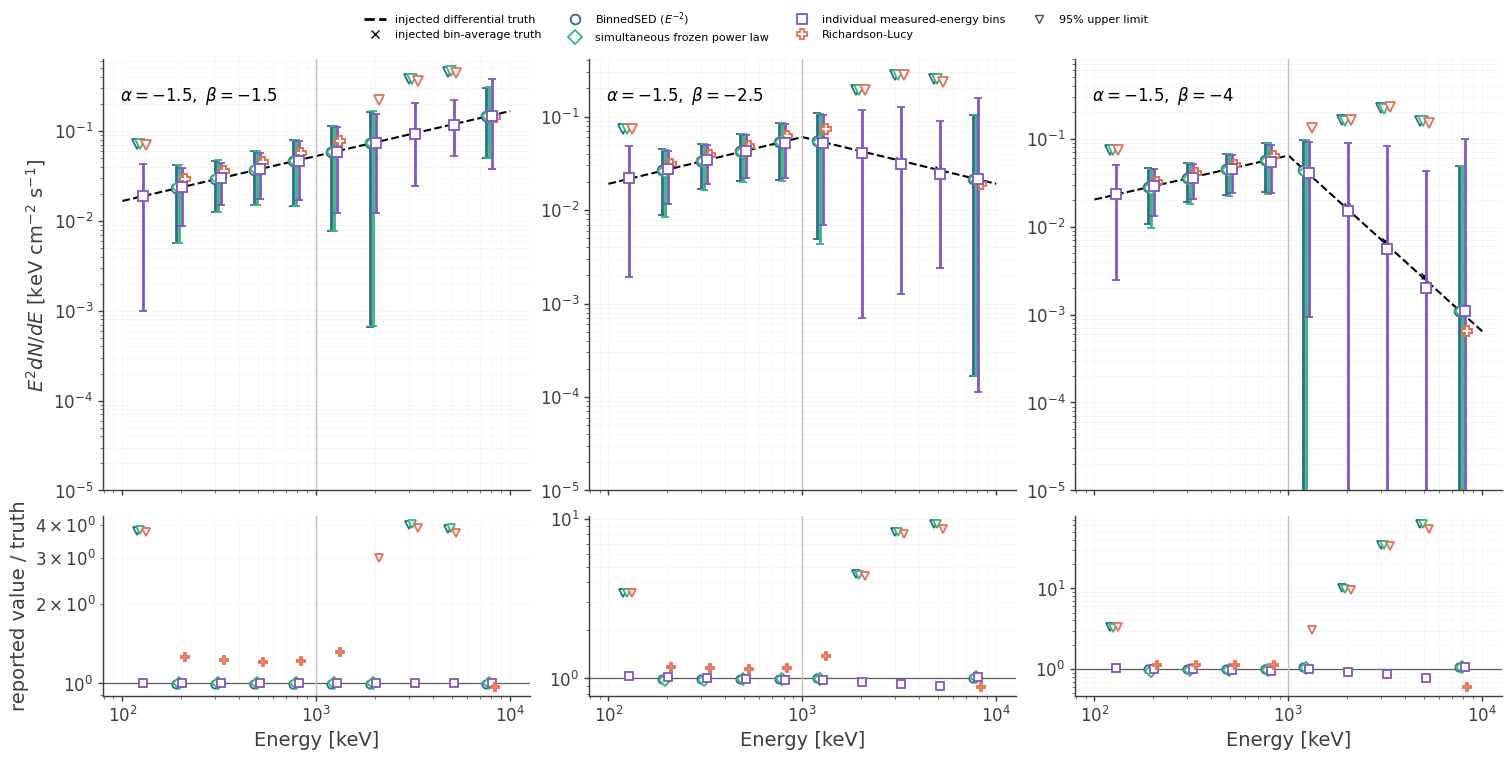

In [9]:
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator

METHOD_STYLE = {
    "simultaneous BinnedSED": {"color": "#31688e", "marker": "o", "offset": 0.95},
    "simultaneous frozen global shape": {"color": "#35b779", "marker": "D", "offset": 0.985},
    "frozen global shape": {"color": "#7e57c2", "marker": "s", "offset": 1.02},
    "Richardson-Lucy": {"color": "#e76f51", "marker": "P", "offset": 1.055},
}
METHOD_LABEL = {
    "simultaneous BinnedSED": r"BinnedSED ($E^{-2}$)",
    "simultaneous frozen global shape": "simultaneous frozen power law",
    "frozen global shape": "individual measured-energy bins",
    "Richardson-Lucy": "Richardson-Lucy",
}

fig, axes = plt.subplots(
    2, 3, figsize=(15, 7.5), sharex="col",
    gridspec_kw={"height_ratios": [3.0, 1.25]}, constrained_layout=True,
)
for column, high_index in enumerate(INJECTED_HIGH_INDICES):
    ax_sed, ax_ratio = axes[:, column]
    energy_grid = np.geomspace(
        comparison_info["energy_edges_keV"][0],
        comparison_info["energy_edges_keV"][-1],
        500,
    )
    truth_grid = _broken_truth(high_index, energy_grid)
    ax_sed.plot(energy_grid, energy_grid**2 * truth_grid, "k--", lw=1.5)
    energy_centers = np.sqrt(
        comparison_info["energy_edges_keV"][:-1]
        * comparison_info["energy_edges_keV"][1:]
    )
    band_truth = _broken_band_average(high_index)
    ax_sed.plot(
        energy_centers, energy_centers**2 * band_truth,
        marker="x", color="k", ls="none", ms=5,
    )

    for method, style in METHOD_STYLE.items():
        subset = sed_comparison[
            (sed_comparison["injected_high_index"] == high_index)
            & (sed_comparison["method"] == method)
        ].sort_values("bin")
        energy = subset["energy_keV"].to_numpy()
        x = style["offset"] * energy
        flux = subset["flux"].to_numpy()
        truth = (
            _broken_band_average(high_index)
            if method == "Richardson-Lucy"
            else _broken_truth(high_index, energy)
        )
        is_ul = subset["is_ul"].to_numpy(dtype=bool)
        detected = ~is_ul

        if detected.any():
            if method == "Richardson-Lucy":
                ax_sed.plot(
                    x[detected], energy[detected] ** 2 * flux[detected],
                    ls="none", marker=style["marker"], ms=7,
                    mfc="white", mec=style["color"], mew=1.4,
                )
            else:
                yerr = np.vstack((
                    energy[detected] ** 2
                    * (flux[detected] - subset["flux_low"].to_numpy()[detected]),
                    energy[detected] ** 2
                    * (subset["flux_high"].to_numpy()[detected] - flux[detected]),
                ))
                ax_sed.errorbar(
                    x[detected], energy[detected] ** 2 * flux[detected],
                    yerr=yerr, fmt=style["marker"], ms=7, mfc="white",
                    mec=style["color"], mew=1.3, ecolor=style["color"],
                    capsize=3, ls="none",
                )
            ax_ratio.plot(
                x[detected], flux[detected] / truth[detected], ls="none",
                marker=style["marker"], ms=6, mfc="white",
                mec=style["color"], mew=1.3,
            )
        if is_ul.any():
            ul = subset["ul95"].to_numpy()[is_ul]
            ax_sed.plot(
                x[is_ul], energy[is_ul] ** 2 * ul, ls="none", marker="v",
                ms=7, mfc="white", mec=style["color"], mew=1.3,
            )
            ax_ratio.plot(
                x[is_ul], ul / truth[is_ul], ls="none", marker="v",
                ms=6, mfc="white", mec=style["color"], mew=1.3,
            )

    ax_sed.axvline(BREAK_ENERGY_KEV, color="0.75", lw=1.0)
    ax_ratio.axvline(BREAK_ENERGY_KEV, color="0.75", lw=1.0)
    ax_sed.text(
        0.04, 0.94,
        rf"$\alpha={INJECTED_LOW_INDEX:g},\ \beta={high_index:g}$",
        transform=ax_sed.transAxes, va="top",
    )
    ax_sed.set(xscale="log", yscale="log")
    ax_sed.set_ylim(bottom=1.0e-5)
    ax_ratio.set(xscale="log", yscale="log")
    ax_ratio.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
    ax_ratio.axhline(1.0, color="0.3", lw=0.9, zorder=0)
    ax_ratio.set_xlabel("Energy [keV]")
    for axis in (ax_sed, ax_ratio):
        axis.grid(alpha=0.18, which="both")

axes[0, 0].set_ylabel(r"$E^2dN/dE$ [keV cm$^{-2}$ s$^{-1}$]")
axes[1, 0].set_ylabel("reported value / truth")
legend_handles = [
    Line2D([], [], color="k", ls="--", label="injected differential truth"),
    Line2D([], [], color="k", marker="x", ls="none", label="injected bin-average truth"),
    *[
        Line2D([], [], color=style["color"], marker=style["marker"], ls="none",
               mfc="white", mew=1.3, ms=7, label=METHOD_LABEL[method])
        for method, style in METHOD_STYLE.items()
    ],
    Line2D([], [], color="0.3", marker="v", ls="none", mfc="white", label="95% upper limit"),
]
fig.legend(handles=legend_handles, loc="outside upper center", ncol=4, frameon=False)
plt.show()
